# Homogeneous coordinates

## Linear transformations

The equation of a linear geometric transformation can be written concisely using matrix multiplication. For instance, the following transformation maps a 
vector ${\bf x}$ onto a vector ${\bf x}^\prime$: 

$$
\begin{align}
    {\bf x}^\prime = SR\,{\bf x},
\end{align}
$$

where $S$ is a scaling matrix and $R$ is a rotation matrix. In 2-D, the scaling and rotation are given by the following matrices: 

$$
\begin{align}
S = \left[
\begin{array}{c}		
   s_x & 0 \\		
   0 & s_y 
\end{array}
\right] \,\,\,\,\text{and} \,\,\,
R= \left[
    \begin{array}{c}		
        \cos\theta & -\sin\theta\\	
        \sin\theta & \cos\theta		
    \end{array}
\right].
\end{align}
$$








Matrices $S$ and $R$ represent linear transformations, and so does the composition $SR$. Here, the rotation transformation is applied to  vector ${\bf x}$ first, and then the scaling transformation is applied to the rotated vector.  

Using this compact form of the transformation matrix simplifies both its computation and notation. For example, we can change the order in which the transformations are applied by simply changing the order of multiplication, i.e.:  

$$
\begin{align}
    {\bf x}^{\prime\prime} = RS\,{\bf x}.
\end{align}
$$

In this case, the scaling transformation is applied to vector ${\bf x}$ first, and then the rotation transformation is applied to the scaled vector.

The inverse transformation is another operation that we can do easily when using matrices to represent linear transformations. The inverse 
of ${\bf x}^\prime = SR\,{\bf x}$ can be written as: 

$$
\begin{align}
    {\bf x} = (SR)^{-1}\,{\bf x}^\prime = (R^{-1}S^{-1})\,{\bf x}^\prime.
\end{align}
$$

## Affine transformations

However, the notation compactness of matrix multiplication "breaks" if the transformation includes a translation vector ${\bf t}$ as it happens in the case of affine transformations. An affine transformation includes a linear component and a translation component and is written as follows:

$$
\begin{align}
    {\bf x}^\prime = A{\bf x} + {\bf t}.
\end{align}
$$

In 2-D, the matrix form of the affine transformation can be written explicitly 
as: 

$$
\begin{align}
    \left[\begin{array}{c}		x^\prime \\		y^\prime\end{array}\right] = \left[\begin{array}{c}		
    a_1 & a_2 \\		a_3 & a_4\end{array}\right]\left[\begin{array}{c}    x \\        
    y\end{array}\right]+\left[\begin{array}{c}    t_x \\        t_y\end{array}\right].
\end{align}
$$

Because the affine transformation combines a multiplication followed by a addition, its equation can no longer be represented by a single matrix or by multiplications only. Instead, we have to mix a matrix multiplication and vector addition (i.e., column matrix representing the translation vector).  

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


### Creating a (helper) function that displays two shapes 
The example described in this code will display the two shapes so we can compare the original shape and its transformed version.
The following function displays the two shapes on a single axis for visualization purposes. 

In [26]:
def plotTwoPolygons(X1: np.ndarray = np.array([]), 
                    X2: np.ndarray = np.array([]),
                    plot_title: str = None):
    """
    Plots two polygons. It is just a helper function to show the 
    difference between the original 2-D shape and its transformed 
    version after some linear transformation. 

    Parameters
    ----------
    X1: numpy.ndarray, shape=(2, N)
        2 x N array containing the (x, y) coordinates of a polygon
        
    X2: numpy.ndarray, shape=(2, N)
        2 x N array containing the (x, y) coordinates of a polygon

    Returns
    -------
    Nothing.

    """
     
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_xlim(-1,10)
    ax.set_ylim(-1,10)
    plt.grid(True)

    if X1.size != 0:
        poly1 = mpl.patches.Polygon(X1.transpose(),fc='blue',alpha=0.5,zorder=1,linewidth=2,edgecolor='k')
        ax.add_patch(poly1)
        ax.plot(X1[0,:], X1[1,:], 'bo')  # plot x and y using circle markers
       
        
    if X2.size != 0: 
        poly2 = mpl.patches.Polygon(X2.transpose(),fc='red',alpha=0.5,zorder=99,linewidth=2,edgecolor='k')
        ax.add_patch(poly2)
        ax.plot(X2[0,:], X2[1,:], 'ro')  # plot x and y using circle markers


    plt.title(plot_title)

    plt.show()  

### The shape to be transformed

The example is a rectangle given by four vertices.

In [27]:
# Vertices of a polygon. First vertex is repeated to 
# close the polygon shape. 
px = np.array([0, 4, 4, 0, 0]);   # x-coords
py = np.array([0, 0, 2, 2, 0]);   # y-coords  

# Create a 2 x N matrix to store the coordinates of the shape
X = np.array([px, 
              py])

print("Input shape =\n", X)

Input shape =
 [[0 4 4 0 0]
 [0 0 2 2 0]]


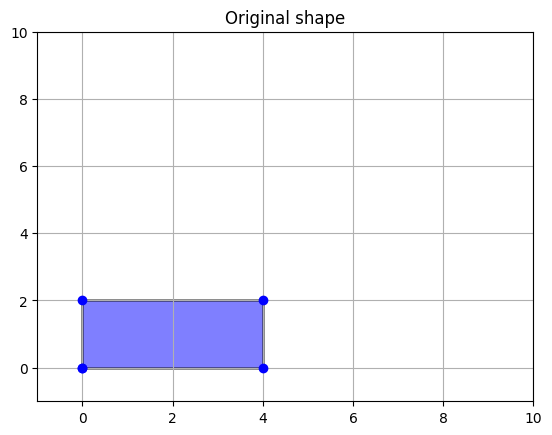

In [28]:
# Plot the orginal shape
plotTwoPolygons(X1 = X, plot_title = "Original shape")

### Transformations
Transformations will be Scaling, Rotation, and translation.

In [29]:
# An example of an affine transformation  
# Scaling transformation (explicit form)
S = np.array([[2.0, 0.0], 
             [0.0, 1.0]])
S

# Rotation
theta = np.pi/8.0 
R = np.array([[ np.cos(theta), -np.sin(theta)],
              [ np.sin(theta),  np.cos(theta)]])

# Translation part of the affine transformation
t = np.array([ [2],  
               [3] ] )

print("Scaling matrix =\n", S)
print("")
print("Rotation matrix =\n", R)
print("")
print("Translation vector =\n", t)

Scaling matrix =
 [[2. 0.]
 [0. 1.]]

Rotation matrix =
 [[ 0.92387953 -0.38268343]
 [ 0.38268343  0.92387953]]

Translation vector =
 [[2]
 [3]]


### Apply transformation to shape
The transformations that we will apply to the rectangle is a Rotation followed by a Scaling and then a Translation, i.e.: 

$$
\begin{align}
    {\bf x}^\prime = (SR)\,{\bf x} + {\bf t}
\end{align}
$$

In [30]:
Xp = (S @ R) @ X + t
print("Transformed points:")
Xp

Transformed points:


array([[2.        , 9.39103626, 7.86030253, 0.46926627, 2.        ],
       [3.        , 4.53073373, 6.37849279, 4.84775907, 3.        ]])

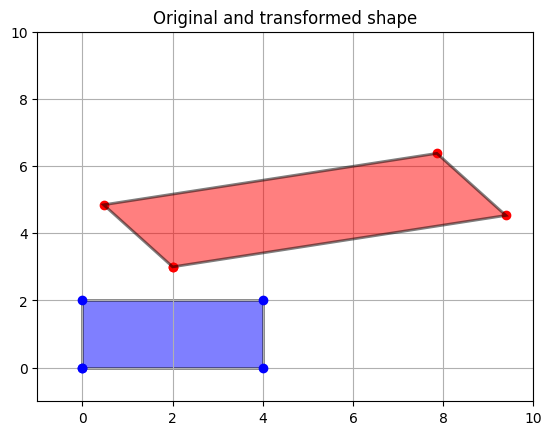

In [31]:
# Plot the original and the transformed shape
plotTwoPolygons(X1 = X, X2 = Xp, plot_title = "Original and transformed shape")

### Example using the inverse affine transformation

To see how the inclusion of the translation further complicates the matrix notation, let us calculate the inverse of the affine transformation in the previous equation. The inverse of ${\bf x}^\prime = (SR)\,{\bf x} + {\bf t}$ is:
$$
\begin{align}
{\bf x} &= (SR)^{-1}\left({\bf x}^\prime - {\bf t}\right) \\
        &= R^{-1}S^{-1}\left({\bf x}^\prime - {\bf t}\right) \\
        &= R^{-1}S^{-1}{\bf x}^\prime - R^{-1}S^{-1}{\bf t}. 
        \label{inverseT}
\end{align}
$$

With this inverse equation, we can go from the transformed shape back to the original shape. Let's do exactly that in the next example.

In [32]:
# Input shape is the transformed shape from the previous example
print("Shape to be transformed:")
Xp

Shape to be transformed:


array([[2.        , 9.39103626, 7.86030253, 0.46926627, 2.        ],
       [3.        , 4.53073373, 6.37849279, 4.84775907, 3.        ]])

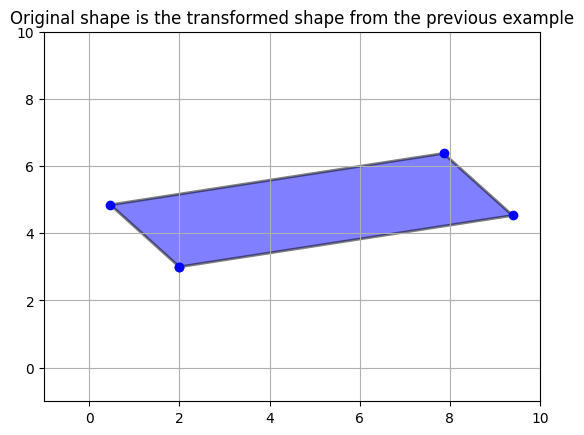

In [33]:
# This time, let's display the transformed shape in blue to indicate that it is our start shape, before transformation. 
plotTwoPolygons(X1 = Xp, plot_title = "Original shape is the transformed shape from the previous example")

In [34]:
# Calculate the shape produced by the inverse affine 
Xi = np.linalg.inv(R) @ np.linalg.inv(S) @ Xp - np.linalg.inv(R) @ np.linalg.inv(S) @ t 

# Transform this shape using the inverse affine matrix 
print('This is the shape resulting from the inverse affine transformation:\n')
print('Xi =\n', Xi)

This is the shape resulting from the inverse affine transformation:

Xi =
 [[0.0000000e+00 4.0000000e+00 4.0000000e+00 4.4408921e-16 0.0000000e+00]
 [0.0000000e+00 4.4408921e-16 2.0000000e+00 2.0000000e+00 0.0000000e+00]]


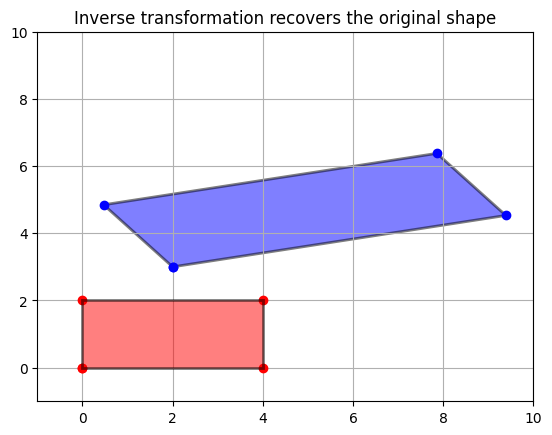

In [35]:
# Display both shapes (original and transformed)
plotTwoPolygons(X1 = Xp, X2 = Xi, plot_title = "Inverse transformation recovers the original shape")

### Representing transformation matrices using homogeneous coordinates
In the previous examples, we were using *Cartesian coordinates* (https://en.wikipedia.org/wiki/Cartesian_coordinate_system) to represent the points (and shapes) to be transformed. Instead of using Cartesian coordinates, we can use *Homogeneous coordinates* to create a concise matrix notation of the affine transformation. This is done 
by augmenting the Cartesian coordinates with an extra non-zero coordinate value, 
which, for simplicity, is usually chosen to be 1.

To convert points from Cartesian to Homogeneous coordinates, we simply augment the original vector by adding 1 as an extra coordinate (i.e., 
dimension), i.e.: 

$$
\left[\begin{array}{c}		
    x \\		y 
\end{array}\right] 
\rightarrow\lambda\left[
\begin{array}{c}		
    x \\		y \\                1
\end{array}\right].
$$

To convert homogenous coordinates back to Cartesian, we need only to divide the homogeneous coordinates as follows: 

$$
\left[\begin{array}{c} \tilde{x} \\ \tilde{y} \\ \tilde{w}\end{array}\right]
\rightarrow
\left[\begin{array}{c} \tilde{x}/\tilde{w} \\ \tilde{y}/\tilde{w}\end{array}\right],
\qquad \tilde{w} \neq 0.
$$

Note that we divide by the **third coordinate**, whatever it happens to be. Writing
$\lambda\,(x, y, 1)^\mathsf{T}$, the entries are $(\lambda x, \lambda y, \lambda)$,
so the division returns $(x, y)$ as it should.

Because, we augmented the vectors, we must also augment the transformation 
matrices that will act on those vectors. 


### The affine transformation in homogeneous coordinates
We now repeat our previous examples of affine transformations but this 
time using homogeneous coordinates instead of Cartesian. The 2-D affine transformation 
in homogeneous coordinates is given by: 

$$
\begin{align}
\left[\begin{array}{c}		x^\prime \\		y^\prime \\                 1
\end{array}\right] 
= \left[\begin{array}{c}		a_1 & a_2  & t_x\\		a_3 & a_4  & t_y\\                  
0  &   0    &   1\end{array}\right]\left[\begin{array}{c}    x \\        y \\    
1\end{array}\right].
\end{align}
$$

This single matrix in homogeneous coordinates incorporates both the linear 
part of the affine and its translation. 


### Scaling 
In homogeneous coordinates, the scaling 
matrix is given by: 

$$
\begin{align}
S_h = \left[
\begin{array}{c}		
   s_x & 0  &  0\\		
   0 & s_y  &  0\\                  
   0  & 0  &   1
    \end{array}
    \right].
\end{align}
$$

### Rotation 
The rotation in homegeneous coordinates is given by: 

$$
\begin{align}
    R_h= \left[\begin{array}{c}		\cos\theta & -\sin\theta & 0 \\		\sin\theta 
    & \cos\theta & 0 \\		0 & 0 & 1 \end{array}\right].
\end{align}
$$


### Translation 

Most importantly, we can now also represent the translation as a matrix, which 
is something that we could not do in Cartesian coordinates. The matrix of the 2-D translation  in homogeneous coordinates is given by: 

$$
\begin{align}
T_h = \left[\begin{array}{c}		1 & 0 & t_x \\		0 & 1 & t_y \\		0 & 0 & 1 \end{array}\right].
\end{align}
$$


In homogeneous coordinates, we can write compositions and inverses of 
transformations more concisely than in Cartesian coordinates. For example, the transformation: 


$$
\begin{align}
	{\bf x}^\prime = SR\,{\bf x} + {\bf t},  
\end{align}
$$

can be written in homogeneous coordinates as:

$$
\begin{align}
	\tilde{\bf x}^\prime = T_hS_hR_h\,\tilde{\bf x}.
\end{align}
$$


Its inverse would be simply: 

$$
\begin{align}
 \tilde{\bf x}   &= \left(T_h\,S_h\,R_h\right)^{-1}\,\tilde{\bf x}^\prime \\
                 &= R_h^{-1}\,S_h^{-1}\,T_h^{-1}\,\tilde{\bf x}^\prime.
\end{align}
$$

In these equations, the subscript $h$ is being used to indicate the homogeneous 
version of the transformation. However, we do not usually explicitly differentiate 
the transformations.  

### Example

In [36]:
# An example of an affine transformation in homogeneous coordinates (using block notation of matrices). 
# I am re-using and augmenting the previous transformation matrices.

# Scaling
S_h = np.block([[S,                np.zeros((2, 1))],
                [np.zeros((1, 2)),                1]])



print('2-D Scaling in homogeneous coordinates:\n') 
print('S_h = ', np.array2string(S_h, prefix='Array: '))

# Rotation
R_h = np.block([[R,                np.zeros((2, 1))],
                [np.zeros((1, 2)),                1]])

print('\n2-D Rotation in homogeneous coordinates:\n') 
print('R_h = ', np.array2string(R_h, prefix='Array: '))

# Translation 
T_h = np.block([[np.eye(2,2),                     t],
                [np.zeros((1, 2)),                1]])



print('\n2-D Translation in homogeneous coordinates:\n') 
print('T_h = ', np.array2string(T_h, prefix='Array: '))




2-D Scaling in homogeneous coordinates:

S_h =  [[2. 0. 0.]
        [0. 1. 0.]
        [0. 0. 1.]]

2-D Rotation in homogeneous coordinates:

R_h =  [[ 0.92387953 -0.38268343  0.        ]
        [ 0.38268343  0.92387953  0.        ]
        [ 0.          0.          1.        ]]

2-D Translation in homogeneous coordinates:

T_h =  [[1. 0. 2.]
        [0. 1. 3.]
        [0. 0. 1.]]


### Shape to be transformed
Here, we will use the same shape(s) as in the previous examples. 

In [37]:
print("Input shape: \n")
print('X =', np.array2string(X, prefix='    '))

Input shape: 

X = [[0 4 4 0 0]
     [0 0 2 2 0]]


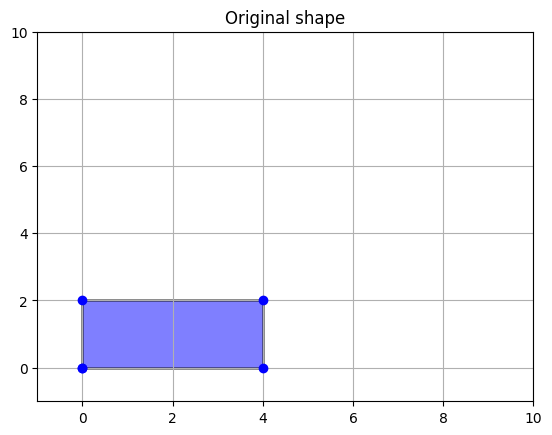

In [38]:
# Plot the orginal shape
plotTwoPolygons(X1 = X, plot_title = "Original shape")

We will then combine the transformations using matrix multiplication only to achieve the affine transformation, i.e.: 
$$
\begin{align}
	\tilde{\bf x}^\prime = T_hS_hR_h\,\tilde{\bf x}.
\end{align}
$$


Before we calculate the transformation, we need to convert the coordinates from Cartesian to homogeneous. As pointed out earlier,  
we add 1 as an extra coordinate. We choose $\lambda = 1$. 
$$
\left[\begin{array}{c}		
    x \\		y 
\end{array}\right] 
\rightarrow\lambda\left[
\begin{array}{c}		
    x \\		y \\                1
\end{array}\right].
$$


In [39]:
# Convert shape points from Cartesian to Homogeneous
ncols = X.shape[1]

X_h = np.block([[X],
               [np.ones((1, ncols))]])


print("Input shape (homogeneous coords): \n")
print('X_h =', np.array2string(X_h, prefix='      '))



Input shape (homogeneous coords): 

X_h = [[0. 4. 4. 0. 0.]
       [0. 0. 2. 2. 0.]
       [1. 1. 1. 1. 1.]]


In [40]:
# Affine transformation by combining transformations in homogeneous coordinates
Xp_h = T_h @ S_h @ R_h @ X_h

print("Transformed shape (homogeneous coords): \n")
print('Xp_h =', np.array2string(Xp_h, prefix='       '))

Transformed shape (homogeneous coords): 

Xp_h = [[2.         9.39103626 7.86030253 0.46926627 2.        ]
        [3.         4.53073373 6.37849279 4.84775907 3.        ]
        [1.         1.         1.         1.         1.        ]]


The calculations were done using homogeneous coordinates to represent the shape. The actual shape is represented in Cartesian coordinates. Thus, we must convert the shape back to Cartesian. 

To convert homogenous coordinates back to Cartesian, we need only to divide 
the homogeneous coordinates as follows: 

$$
\left[\begin{array}{c} \tilde{x} \\ \tilde{y} \\ \tilde{w}\end{array}\right]
\rightarrow
\left[\begin{array}{c} \tilde{x}/\tilde{w} \\ \tilde{y}/\tilde{w}\end{array}\right],
\qquad \tilde{w} \neq 0.
$$


In [41]:
# Convert shape representation from homogeneous to Cartesian (using vectorized calculation for speed and concise code)
Xp = Xp_h[0:2,:] / Xp_h[2,:]

print("Transformed shape (Cartesian coords): \n")
print('Xp =', np.array2string(Xp, prefix='     '))


Transformed shape (Cartesian coords): 

Xp = [[2.         9.39103626 7.86030253 0.46926627 2.        ]
      [3.         4.53073373 6.37849279 4.84775907 3.        ]]


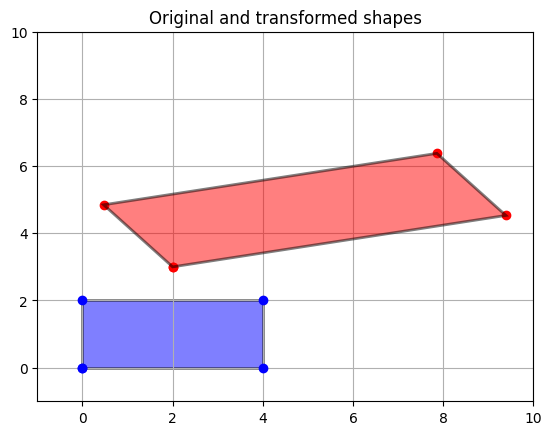

In [42]:
# Now, display the shape (Remember, we can only display the shape after we convert it to Cartesian coordinates)
plotTwoPolygons(X1 = X, X2 = Xp, plot_title = "Original and transformed shapes")

### Using the inverse in homogeneous coordinates 
The following example shows the use of the inverse transformation. This time, the notation is more concise because we will use homogeneous coordinates instead of Cartesian coordinates. 

Recall that the inverse of the transformation is:
$$
\begin{align}
 \tilde{\bf x}   &= \left(T_h\,S_h\,R_h\right)^{-1}\,\tilde{\bf x}^\prime \\
                 &= R_h^{-1}\,S_h^{-1}\,T_h^{-1}\,\tilde{\bf x}^\prime.
\end{align}
$$


In [43]:
# Using the inverse transformation to revert the "transformed" shape to its original shape
Xi_h = np.linalg.inv(R_h) @ np.linalg.inv(S_h) @ np.linalg.inv(T_h) @ Xp_h


# Transform this shape using the inverse affine matrix 
print('This is original shape calculated by the inverse transformation:\n')
print('Xi_h =', np.array2string(Xi_h, prefix='       ', precision=1))


This is original shape calculated by the inverse transformation:

Xi_h = [[0.0e+00 4.0e+00 4.0e+00 4.4e-16 0.0e+00]
        [0.0e+00 4.4e-16 2.0e+00 2.0e+00 0.0e+00]
        [1.0e+00 1.0e+00 1.0e+00 1.0e+00 1.0e+00]]


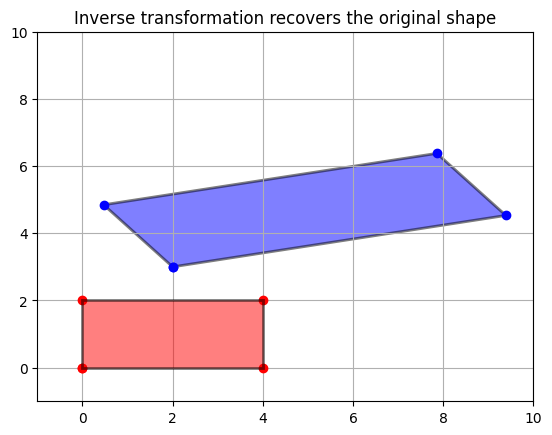

In [44]:
# Convert shape back to Cartesian coords and display both shapes
Xi_new = Xi_h[0:2,:] / Xi_h[2,:]
Xp_new = Xp_h[0:2,:] / Xp_h[2,:]


# Display both shapes (original and transformed)
plotTwoPolygons(X1 = Xp_new, X2 = Xi_new, plot_title = "Inverse transformation recovers the original shape")

## What the extra coordinate actually buys us

So far the third coordinate has looked like bookkeeping: a row of ones that lets
translation become a matrix. That alone is worth it, but it undersells what the
extra coordinate does.

The three sections below show the rest of it:

1. the scale $\lambda$ is genuinely free --- a homogeneous point is a *ray*, not a
   single vector;
2. setting $w = 0$ names something Cartesian coordinates cannot name at all: a
   **direction**, or equivalently a **point at infinity**;
3. once the bottom row of the matrix is allowed to be something other than
   $(0,0,1)$, the transformation becomes **projective**, parallel lines stop
   being parallel, and points at infinity land somewhere you can actually see ---
   a **vanishing point**.

### 1. The scale $\lambda$ is free

$\tilde{\bf x}$ and $\lambda\tilde{\bf x}$ represent the **same** Cartesian point
for any $\lambda \neq 0$. The homogeneous coordinates of a point are only defined
up to scale --- what is really being represented is the whole ray through the
origin.

This is why we can pick $\lambda = 1$ when converting *into* homogeneous
coordinates, and why we must divide by the third coordinate when converting back.

In [45]:
# The same shape, with two different choices of lambda
X_h_1 = X_h            # lambda = 1, the usual choice
X_h_7 = 7.0 * X_h      # lambda = 7

print("one vertex, lambda = 1 :", X_h_1[:, 1])
print("one vertex, lambda = 7 :", X_h_7[:, 1])

# Convert both back to Cartesian: divide by the THIRD coordinate
back_1 = X_h_1[0:2, :] / X_h_1[2, :]
back_7 = X_h_7[0:2, :] / X_h_7[2, :]

print("\nboth give the same Cartesian shape:", np.allclose(back_1, back_7))
print("\nCartesian shape =\n", back_1)

one vertex, lambda = 1 : [4. 0. 1.]
one vertex, lambda = 7 : [28.  0.  7.]

both give the same Cartesian shape: True

Cartesian shape =
 [[0. 4. 4. 0. 0.]
 [0. 0. 2. 2. 0.]]


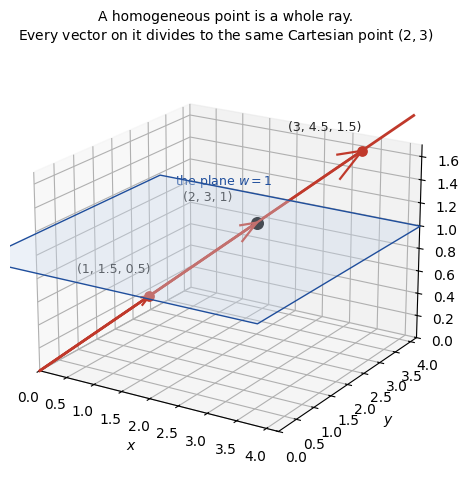

lam =  0.5   homogeneous (1, 1.5, 0.5)      ->  Cartesian (np.float64(2.0), np.float64(3.0))
lam =    1   homogeneous (2, 3, 1)          ->  Cartesian (np.float64(2.0), np.float64(3.0))
lam =  1.5   homogeneous (3, 4.5, 1.5)      ->  Cartesian (np.float64(2.0), np.float64(3.0))
lam =    7   homogeneous (14, 21, 7)        ->  Cartesian (np.float64(2.0), np.float64(3.0))


In [46]:
# A geometric picture of what "up to scale" means.
# The 2-D point (2,3) is the whole ray of vectors {lam * (2,3,1)}; the plane
# w = 1 is simply where we choose to read it off.
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_w_plane(ax, w=1.0, lo=-0.6, hi=4.2, color="#c9d8ec", alpha=0.35):
    """Draw the plane at height w as a translucent patch."""
    corners = [[lo, lo, w], [hi, lo, w], [hi, hi, w], [lo, hi, w]]
    ax.add_collection3d(Poly3DCollection([corners], facecolor=color,
                                         edgecolor="#1f4e9c", alpha=alpha, lw=1))

ray_p = np.array([2.0, 3.0, 1.0])        # the point (2,3), written with w = 1

fig = plt.figure(figsize=(7.2, 5.6))
ax = fig.add_subplot(111, projection="3d")
plot_w_plane(ax, 1.0)

ray_s = np.linspace(0, 1.75, 50)                    # the ray through the origin
ax.plot(ray_p[0]*ray_s, ray_p[1]*ray_s, ray_p[2]*ray_s, color="#c0392b", lw=2)

for lam in (0.5, 1.0, 1.5):                         # three vectors on that ray
    ray_q = lam * ray_p
    ax.quiver(0, 0, 0, *ray_q, color="#c0392b", lw=1.6, arrow_length_ratio=0.08)
    ax.scatter(*ray_q, color="#c0392b", s=45, depthshade=False)
    ax.text(ray_q[0]-1.35, ray_q[1], ray_q[2]+0.06,
            "({:g}, {:g}, {:g})".format(*ray_q), fontsize=9, color="0.15")

ax.scatter(*ray_p, color="k", s=70, depthshade=False)
ax.text(0.1, 3.6, 1.06, r"the plane $w=1$", fontsize=9, color="#1f4e9c")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_zlabel("$w$")
ax.set_xlim(0, 4.2); ax.set_ylim(0, 4.2); ax.set_zlim(0, 1.7)
ax.set_title("A homogeneous point is a whole ray.\n"
             r"Every vector on it divides to the same Cartesian point $(2,3)$",
             fontsize=10)
ax.view_init(20, -58)
plt.show()

# the same statement, numerically
for lam in (0.5, 1.0, 1.5, 7.0):
    ray_q = lam * ray_p
    homog = "({:g}, {:g}, {:g})".format(*ray_q)
    cart = tuple(np.round(ray_q[0:2] / ray_q[2], 6))
    print("lam = {:4g}   homogeneous {:<18s} ->  Cartesian {}".format(lam, homog, cart))

### 2. $w = 0$ --- points at infinity

Nothing forces the third coordinate to be non-zero. If we set $w = 0$ we get

$$
\begin{align}
\tilde{\bf d} = \left[\begin{array}{c} d_x \\ d_y \\ 0\end{array}\right],
\end{align}
$$

which has **no** Cartesian equivalent --- converting it would require dividing by
zero. It is not a location. It is a **direction**, and it is what we mean by a
*point at infinity*: the place where all lines with direction $(d_x, d_y)$ would
meet.

A quick sanity check on that claim: a translation should be unable to move a
direction, because sliding a set of parallel lines sideways does not change which
way they point. In homogeneous coordinates this falls out of the algebra, since
the translation column is multiplied by $w = 0$.

In [47]:
# The direction in which the two horizontal edges of our square point
d = np.array([1.0, 0.0, 0.0])       # w = 0  ->  a direction, not a place

print("direction as a homogeneous point:", d)

# A translation cannot move it: the translation column is multiplied by w = 0
print("\nT_h @ d =", T_h @ d, "  <- unchanged")

# Neither can any affine transformation: the bottom row (0, 0, 1) keeps w = 0
print("(T_h @ S_h @ R_h) @ d =", (T_h @ S_h @ R_h) @ d, "  <- still w = 0")
print("\nSo under an affine transformation, a point at infinity stays at infinity.")

direction as a homogeneous point: [1. 0. 0.]

T_h @ d = [1. 0. 0.]   <- unchanged
(T_h @ S_h @ R_h) @ d = [1.84775907 0.38268343 0.        ]   <- still w = 0

So under an affine transformation, a point at infinity stays at infinity.


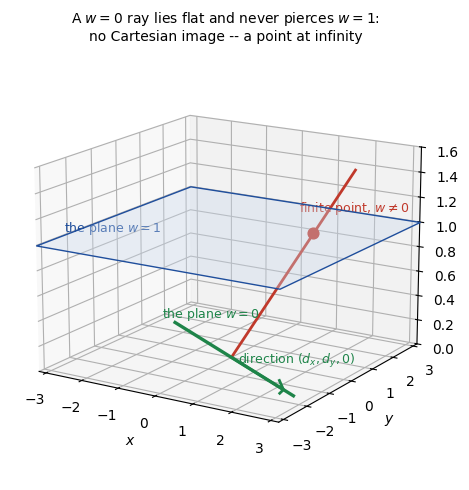

In [48]:
# Why w = 0 is called a point "at infinity": its ray is parallel to the plane
# w = 1, so it never meets it and has no Cartesian image at all.
fig = plt.figure(figsize=(7.2, 5.6))
ax = fig.add_subplot(111, projection="3d")
plot_w_plane(ax, 1.0, lo=-3.2, hi=3.2)

inf_pt = np.array([1.6, 1.0, 1.0])                  # an ordinary point, w != 0
inf_s = np.linspace(0, 1.5, 40)
ax.plot(inf_pt[0]*inf_s, inf_pt[1]*inf_s, inf_pt[2]*inf_s, color="#c0392b", lw=2)
ax.scatter(*inf_pt, color="#c0392b", s=60, depthshade=False)
ax.text(inf_pt[0]-0.4, inf_pt[1], inf_pt[2]+0.16, r"finite point, $w\neq0$",
        fontsize=9, color="#c0392b")

inf_dir = np.array([1.0, -0.6, 0.0])                # a direction, w = 0
inf_u = np.linspace(-2.6, 2.6, 40)
ax.plot(inf_dir[0]*inf_u, inf_dir[1]*inf_u, inf_dir[2]*inf_u, color="#1e8449", lw=2.4)
ax.quiver(0, 0, 0, *(2.2*inf_dir), color="#1e8449", lw=2, arrow_length_ratio=0.09)
ax.text(2.2*inf_dir[0]-1.2, 2.2*inf_dir[1], 0.14, r"direction $(d_x,d_y,0)$",
        fontsize=9, color="#1e8449")
ax.text(-3.0, 1.6, 0.02, r"the plane $w=0$", fontsize=9, color="#1e8449")
ax.text(-3.0, -2.4, 1.06, r"the plane $w=1$", fontsize=9, color="#1f4e9c")

ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_zlabel("$w$")
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2); ax.set_zlim(0, 1.6)
ax.set_title("A $w=0$ ray lies flat and never pierces $w=1$:\n"
             "no Cartesian image -- a point at infinity", fontsize=10)
ax.view_init(16, -58)
plt.show()

### 3. Projective transformations and vanishing points

Every matrix we have used so far had bottom row $(0, 0, 1)$. That is exactly what
makes a transformation **affine**: it keeps $w$ unchanged, so parallel lines stay
parallel and points at infinity stay at infinity.

Allow the bottom row to be anything and the transformation becomes
**projective** --- a homography:

$$
\begin{align}
H = \left[\begin{array}{c}
  h_{11} & h_{12} & h_{13} \\
  h_{21} & h_{22} & h_{23} \\
  h_{31} & h_{32} & h_{33}
\end{array}\right],
\qquad \text{affine is the special case } (h_{31}, h_{32}) = (0,0).
\end{align}
$$

Now $w$ depends on the point, so the division by the third coordinate does
different things in different places --- and a point at infinity can be mapped to
a **finite** point. That image is the **vanishing point** of the corresponding
direction, and it is the reason railway tracks appear to meet in a photograph.

In [49]:
# A projective transformation: the bottom row is no longer (0, 0, 1)
H = np.array([[1.00, 0.0, 0.0],
              [0.00, 1.0, 0.0],
              [0.15, 0.0, 1.0]])

print("H =\n", H)

# Where does the direction d = (1, 0, 0) go?
v_h = H @ d
v   = v_h[0:2] / v_h[2]
print("\nH @ d =", v_h, " -> Cartesian", v)
print("The point at infinity has become a FINITE point: the vanishing point.")

# Transform the square with H
Xp_proj_h = H @ X_h
Xp_proj   = Xp_proj_h[0:2, :] / Xp_proj_h[2, :]

print("\nthird coordinate w, vertex by vertex:", np.round(Xp_proj_h[2, :], 3))
print("  (constant for an affine map; here it varies -- that is the perspective)")
print("\ntransformed square =\n", np.round(Xp_proj, 4))

H =
 [[1.   0.   0.  ]
 [0.   1.   0.  ]
 [0.15 0.   1.  ]]

H @ d = [1.   0.   0.15]  -> Cartesian [6.66666667 0.        ]
The point at infinity has become a FINITE point: the vanishing point.

third coordinate w, vertex by vertex: [1.  1.6 1.6 1.  1. ]
  (constant for an affine map; here it varies -- that is the perspective)

transformed square =
 [[0.   2.5  2.5  0.   0.  ]
 [0.   0.   1.25 2.   0.  ]]


the two image edges meet at : [6.6667 0.    ]
H @ d predicted             : [6.6667 0.    ]
they agree                  : True


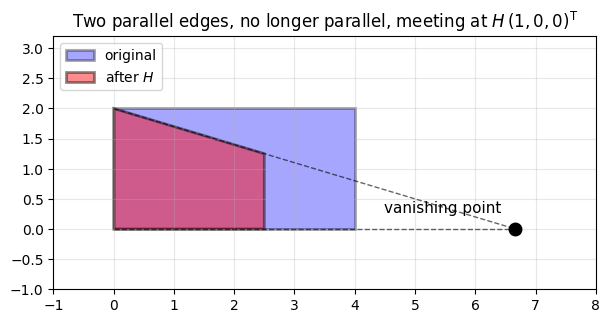

In [50]:
# Do the two originally-parallel edges really meet at the vanishing point?
def line_intersection(a, b, c, e):
    """Intersection of the line through a,b with the line through c,e."""
    M = np.array([b - a, -(e - c)]).T
    s, _ = np.linalg.solve(M, c - a)
    return a + s * (b - a)

bottom = (Xp_proj[:, 0], Xp_proj[:, 1])   # image of the edge (0,0)-(4,0)
top    = (Xp_proj[:, 3], Xp_proj[:, 2])   # image of the edge (0,2)-(4,2)
meeting = line_intersection(bottom[0], bottom[1], top[0], top[1])

print("the two image edges meet at :", np.round(meeting, 4))
print("H @ d predicted             :", np.round(v, 4))
print("they agree                  :", np.allclose(meeting, v))

fig, ax = plt.subplots(figsize=(7, 4))
ax.add_patch(mpl.patches.Polygon(X[:, :4].T, fc='blue', alpha=0.35,
                                 edgecolor='k', linewidth=2, label='original'))
ax.add_patch(mpl.patches.Polygon(Xp_proj[:, :4].T, fc='red', alpha=0.45,
                                 edgecolor='k', linewidth=2, label='after $H$'))
for p, q in (bottom, top):
    ax.plot([p[0], meeting[0]], [p[1], meeting[1]], 'k--', lw=1, alpha=0.6)
ax.plot(*meeting, 'ko', ms=9)
ax.annotate('vanishing point', meeting, textcoords='offset points',
            xytext=(-10, 12), ha='right', fontsize=11)
ax.set_xlim(-1, 8); ax.set_ylim(-1, 3.2); ax.set_aspect('equal')
ax.grid(True, alpha=0.3); ax.legend(loc='upper left')
ax.set_title('Two parallel edges, no longer parallel, meeting at $H\\,(1,0,0)^\\mathsf{T}$')
plt.show()

## Summary

* Homogeneous coordinates add one extra coordinate, so that a point in 2-D is
  written as $(x, y, w)$ rather than $(x, y)$.
* The representation is **up to scale**: $\tilde{\bf x}$ and $\lambda\tilde{\bf x}$
  are the same point. Converting back to Cartesian means **dividing by the last
  coordinate**.
* Translation, which is an *addition* in Cartesian coordinates, becomes a
  *matrix multiplication*. Compositions and inverses are then products of
  matrices, in the same way as for purely linear transformations.
* $w = 0$ names a **direction** --- a point at infinity --- which Cartesian
  coordinates cannot express at all.
* A bottom row of $(0, 0, 1)$ makes the transformation **affine** and keeps
  parallel lines parallel. Any other bottom row makes it **projective**, and
  sends points at infinity to finite **vanishing points**.

That last case is the one a camera performs when it photographs a plane.